<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GSNR_Calculator_for_Subsea_Open_Cables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    N |  Simple (dB) |  Droop (dB) |  Diff (dB)
--------------------------------------------------
    1 |        15.00 |       15.00 |       0.00
    5 |         8.01 |        7.74 |       0.27
   10 |         5.00 |        4.37 |       0.63
   20 |         1.99 |        0.64 |       1.35
   50 |        -1.99 |       -5.73 |       3.74
  100 |        -5.00 |      -13.32 |       8.32
Saved: ase_noise_comparison.png


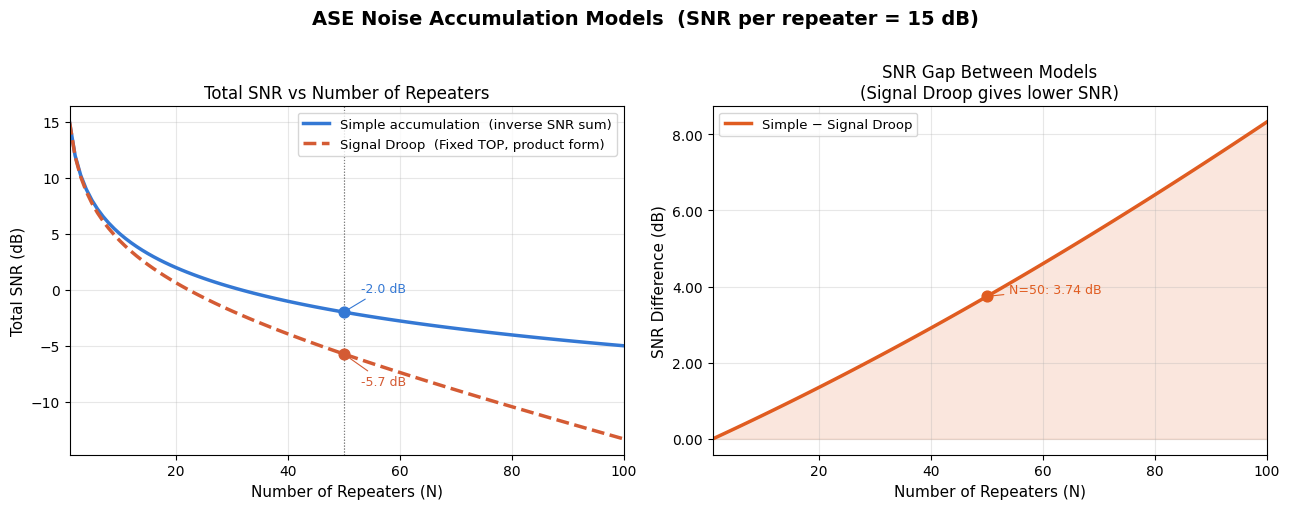

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Settings ──────────────────────────────────────────────
SNR_PER_DB  = 15      # SNR per repeater (dB)
MAX_N       = 100     # max number of repeaters
HIGHLIGHT_N = 50      # N value to annotate

# ── Conversion helpers ────────────────────────────────────
def db_to_linear(dB):
    return 10 ** (dB / 10)

def linear_to_db(lin):
    return 10 * np.log10(lin)

# ── Compute ───────────────────────────────────────────────
snr_per_lin = db_to_linear(SNR_PER_DB)
N = np.arange(1, MAX_N + 1)

# Model 1: Simple accumulation  (1/SNR_total = N/SNR_per)
snr_simple_db = linear_to_db(snr_per_lin / N)

# Model 2: Signal Droop / Fixed TOP
# (1 + 1/SNR_ASE) = (1 + 1/SNR_per)^N
snr_droop_db = linear_to_db(1 / ((1 + 1 / snr_per_lin) ** N - 1))

# ── Print table ───────────────────────────────────────────
print(f"{'N':>5} | {'Simple (dB)':>12} | {'Droop (dB)':>11} | {'Diff (dB)':>10}")
print("-" * 50)
for n in [1, 5, 10, 20, 50, 100]:
    if n <= MAX_N:
        s = snr_simple_db[n - 1]
        d = snr_droop_db[n - 1]
        print(f"{n:>5} | {s:>12.2f} | {d:>11.2f} | {s - d:>10.2f}")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"ASE Noise Accumulation Models  (SNR per repeater = {SNR_PER_DB} dB)",
    fontsize=14, fontweight="bold", y=1.01
)

C_SIMPLE = "#3478d4"
C_DROOP  = "#d45b34"
C_DIFF   = "#e05c20"

# Left: SNR vs N
ax1 = axes[0]
ax1.plot(N, snr_simple_db, color=C_SIMPLE, lw=2.5,
         label="Simple accumulation  (inverse SNR sum)")
ax1.plot(N, snr_droop_db, color=C_DROOP, lw=2.5, linestyle="--",
         label="Signal Droop  (Fixed TOP, product form)")

for arr, col, dy in [(snr_simple_db, C_SIMPLE, +1.8),
                     (snr_droop_db,  C_DROOP,  -2.8)]:
    val = arr[HIGHLIGHT_N - 1]
    ax1.axvline(HIGHLIGHT_N, color="gray", lw=0.8, ls=":")
    ax1.scatter([HIGHLIGHT_N], [val], color=col, zorder=5, s=60)
    ax1.annotate(f"{val:.1f} dB",
                 xy=(HIGHLIGHT_N, val),
                 xytext=(HIGHLIGHT_N + 3, val + dy),
                 fontsize=9, color=col,
                 arrowprops=dict(arrowstyle="-", color=col, lw=0.8))

ax1.set_xlabel("Number of Repeaters (N)", fontsize=11)
ax1.set_ylabel("Total SNR (dB)", fontsize=11)
ax1.set_title("Total SNR vs Number of Repeaters", fontsize=12)
ax1.legend(fontsize=9.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, MAX_N)

# Right: difference between models
ax2 = axes[1]
diff_db = snr_simple_db - snr_droop_db   # positive → Droop gives lower SNR
ax2.fill_between(N, diff_db, alpha=0.15, color=C_DIFF)
ax2.plot(N, diff_db, color=C_DIFF, lw=2.5,
         label="Simple − Signal Droop")

val_diff = diff_db[HIGHLIGHT_N - 1]
ax2.scatter([HIGHLIGHT_N], [val_diff], color=C_DIFF, zorder=5, s=60)
ax2.annotate(f"N={HIGHLIGHT_N}: {val_diff:.2f} dB",
             xy=(HIGHLIGHT_N, val_diff),
             xytext=(HIGHLIGHT_N + 4, val_diff + 0.1),
             fontsize=9, color=C_DIFF,
             arrowprops=dict(arrowstyle="-", color=C_DIFF, lw=0.8))

ax2.set_xlabel("Number of Repeaters (N)", fontsize=11)
ax2.set_ylabel("SNR Difference (dB)", fontsize=11)
ax2.set_title("SNR Gap Between Models\n(Signal Droop gives lower SNR)", fontsize=12)
ax2.legend(fontsize=9.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, MAX_N)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

plt.tight_layout()

# ── 수정된 부분: 코랩 기본 경로에 저장되도록 파일명만 입력 ──
plt.savefig("ase_noise_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: ase_noise_comparison.png")

ㅇ

Saved: ./output/ase_signal_droop_power.png


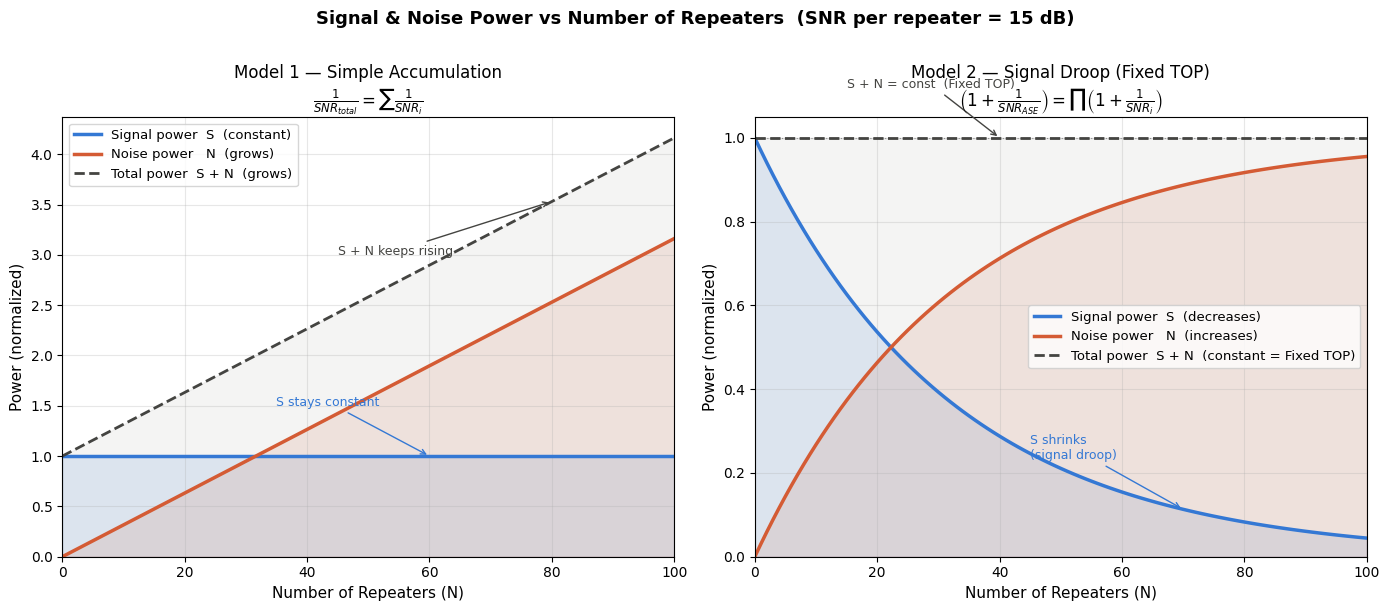


    N |   S_simple |   N_simple |  Total_simple ||   S_droop |   N_droop |  Total_droop
------------------------------------------------------------------------------------------
    0 |     1.0000 |     0.0000 |        1.0000 ||    1.0000 |    0.0000 |       1.0000
    1 |     1.0000 |     0.0316 |        1.0316 ||    0.9693 |    0.0307 |       1.0000
    5 |     1.0000 |     0.1581 |        1.1581 ||    0.8558 |    0.1442 |       1.0000
   10 |     1.0000 |     0.3162 |        1.3162 ||    0.7325 |    0.2675 |       1.0000
   20 |     1.0000 |     0.6325 |        1.6325 ||    0.5365 |    0.4635 |       1.0000
   50 |     1.0000 |     1.5811 |        2.5811 ||    0.2108 |    0.7892 |       1.0000
  100 |     1.0000 |     3.1623 |        4.1623 ||    0.0445 |    0.9555 |       1.0000


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ── Settings ──────────────────────────────────────────────
SNR_PER_DB = 15          # SNR per repeater (dB)
MAX_N      = 100         # max number of repeaters
S0         = 1.0         # initial signal power (normalized)

# ── Helpers ───────────────────────────────────────────────
def db_to_linear(dB):
    return 10 ** (dB / 10)

snr_per = db_to_linear(SNR_PER_DB)   # linear
N_noise = S0 / snr_per               # ASE noise power added per repeater
N       = np.arange(0, MAX_N + 1)    # repeater count (0 = no repeater)

# ══════════════════════════════════════════════════════════
# Model 1: Simple accumulation
#   Signal stays at S0, noise just piles up
# ══════════════════════════════════════════════════════════
S_simple     = np.full_like(N, S0, dtype=float)
N_simple     = N * N_noise
Total_simple = S_simple + N_simple

# ══════════════════════════════════════════════════════════
# Model 2: Signal Droop  (Fixed TOP = S0)
#   Total power S + N = S0 = const
#   SNR(n) = 1 / ((1 + 1/snr_per)^n - 1)   for n >= 1
#   S(n) = S0 * SNR(n) / (1 + SNR(n))
#   N(n) = S0 / (1 + SNR(n))
# ══════════════════════════════════════════════════════════
snr_droop = np.zeros(MAX_N + 1)
S_droop   = np.zeros(MAX_N + 1)
N_droop   = np.zeros(MAX_N + 1)

snr_droop[0] = np.inf
S_droop[0]   = S0
N_droop[0]   = 0.0

for n in range(1, MAX_N + 1):
    factor        = (1 + 1 / snr_per) ** n - 1
    snr_droop[n]  = 1 / factor
    S_droop[n]    = S0 * snr_droop[n] / (1 + snr_droop[n])
    N_droop[n]    = S0 / (1 + snr_droop[n])

Total_droop = S_droop + N_droop    # should be S0 throughout

# ══════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle(
    f"Signal & Noise Power vs Number of Repeaters  (SNR per repeater = {SNR_PER_DB} dB)",
    fontsize=13, fontweight="bold", y=1.01
)

C_S     = "#3478d4"    # signal  → blue
C_N     = "#d45b34"    # noise   → red-orange
C_TOTAL = "#444441"    # total   → dark gray

ALPHA_FILL = 0.12

# ── Left: Simple accumulation ─────────────────────────────
ax = axes[0]

ax.fill_between(N, S_simple,     alpha=ALPHA_FILL, color=C_S)
ax.fill_between(N, N_simple,     alpha=ALPHA_FILL, color=C_N)
ax.fill_between(N, Total_simple, alpha=0.06,       color=C_TOTAL)

ax.plot(N, S_simple,     color=C_S,     lw=2.5, label="Signal power  S  (constant)")
ax.plot(N, N_simple,     color=C_N,     lw=2.5, label="Noise power   N  (grows)")
ax.plot(N, Total_simple, color=C_TOTAL, lw=2.0,
        linestyle="--", label="Total power  S + N  (grows)")

ax.set_xlabel("Number of Repeaters (N)", fontsize=11)
ax.set_ylabel("Power (normalized)", fontsize=11)
ax.set_title("Model 1 — Simple Accumulation\n"
             r"$\frac{1}{SNR_{total}} = \sum \frac{1}{SNR_i}$",
             fontsize=12)
ax.legend(fontsize=9.5, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, MAX_N)
ax.set_ylim(bottom=0)

ax.annotate("S stays constant", xy=(MAX_N * 0.6, S0),
            xytext=(MAX_N * 0.35, S0 * 1.5),
            fontsize=9, color=C_S,
            arrowprops=dict(arrowstyle="->", color=C_S, lw=1.0))
ax.annotate("S + N keeps rising", xy=(MAX_N * 0.8, Total_simple[int(MAX_N * 0.8)]),
            xytext=(MAX_N * 0.45, Total_simple[int(MAX_N * 0.8)] * 0.85),
            fontsize=9, color=C_TOTAL,
            arrowprops=dict(arrowstyle="->", color=C_TOTAL, lw=1.0))

# ── Right: Signal Droop (Fixed TOP) ──────────────────────
ax = axes[1]

ax.fill_between(N, S_droop,     alpha=ALPHA_FILL, color=C_S)
ax.fill_between(N, N_droop,     alpha=ALPHA_FILL, color=C_N)
ax.fill_between(N, Total_droop, alpha=0.06,       color=C_TOTAL)

ax.plot(N, S_droop,     color=C_S,     lw=2.5, label="Signal power  S  (decreases)")
ax.plot(N, N_droop,     color=C_N,     lw=2.5, label="Noise power   N  (increases)")
ax.plot(N, Total_droop, color=C_TOTAL, lw=2.0,
        linestyle="--", label="Total power  S + N  (constant = Fixed TOP)")

ax.set_xlabel("Number of Repeaters (N)", fontsize=11)
ax.set_ylabel("Power (normalized)", fontsize=11)
ax.set_title("Model 2 — Signal Droop (Fixed TOP)\n"
             r"$\left(1+\frac{1}{SNR_{ASE}}\right)=\prod\left(1+\frac{1}{SNR_i}\right)$",
             fontsize=12)
ax.legend(fontsize=9.5, loc="center right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, MAX_N)
ax.set_ylim(bottom=0)

ax.axhline(S0, color=C_TOTAL, lw=0.8, ls=":", alpha=0.5)
ax.annotate("S + N = const  (Fixed TOP)", xy=(MAX_N * 0.4, S0),
            xytext=(MAX_N * 0.15, S0 * 1.12),
            fontsize=9, color=C_TOTAL,
            arrowprops=dict(arrowstyle="->", color=C_TOTAL, lw=1.0))
ax.annotate("S shrinks\n(signal droop)", xy=(MAX_N * 0.7, S_droop[int(MAX_N * 0.7)]),
            xytext=(MAX_N * 0.45, S_droop[int(MAX_N * 0.7)] + 0.12),
            fontsize=9, color=C_S,
            arrowprops=dict(arrowstyle="->", color=C_S, lw=1.0))

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────
save_dir = "./output"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f"{save_dir}/ase_signal_droop_power.png", dpi=150, bbox_inches="tight")
print(f"Saved: {save_dir}/ase_signal_droop_power.png")

plt.show()

# ── Numerical summary ─────────────────────────────────────
print(f"\n{'N':>5} | {'S_simple':>10} | {'N_simple':>10} | {'Total_simple':>13}"
      f" || {'S_droop':>9} | {'N_droop':>9} | {'Total_droop':>12}")
print("-" * 90)
for n in [0, 1, 5, 10, 20, 50, 100]:
    print(f"{n:>5} | {S_simple[n]:>10.4f} | {N_simple[n]:>10.4f} | {Total_simple[n]:>13.4f}"
          f" || {S_droop[n]:>9.4f} | {N_droop[n]:>9.4f} | {Total_droop[n]:>12.4f}")